# Minimal Working Example to get spike model

This notebook will contain the minimal code to get the "chosen" model from our spike analysis. 

## quick start

```bash 
mamba create --name multidms_minimal python=3.11
mamba activate multidms_minimal
pip install multidms==1.1.0 notebook
```

import modules

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import multidms

First, we'll load the training data

In [4]:
func_score_df = pd.read_csv("training_functional_scores.csv").fillna("").query("replicate == 1")
func_score_df.head()

,aa_substitutions,condition,replicate,n_subs,func_score
0,,Delta,1,0,0.000000
2,,Omicron_BA1,1,0,0.000000
4,,Omicron_BA2,1,0,0.000000
6,A1015D,Delta,1,1,-1.729935
9,A1015D,Omicron_BA2,1,1,-3.500000


Create the `Data` object

In [5]:
data = multidms.Data(
    func_score_df,
    collapse_identical_variants="mean",       # take the average variant func score across barcode replicates
    alphabet=multidms.AAS_WITHSTOP_WITHGAP,   # 
    reference="Omicron_BA1",
    nb_workers = 4
)

Define the model. This is initializes the model parameters and stores them in the `Model` object. Note that to replicate the manuscript analysis, we initializing the sigmoid parameters to the range in the data.

In [6]:
model = multidms.Model(data, init_theta_scale=6.0, init_theta_bias=-3.5)

In [21]:
help(model.fit)

Help on method fit in module multidms.model:

fit(scale_coeff_lasso_shift=1e-05, tol=0.0001, maxiter=1000, maxls=15, acceleration=True, lock_params={}, admm_niter=50, admm_tau=1.0, warn_unconverged=True, upper_bound_ge_scale='infer', convergence_trajectory_resolution=10, **kwargs) method of multidms.model.Model instance
    Use jaxopt.ProximalGradiant to optimize the model's free parameters.
    
    Parameters
    ----------
    scale_coeff_lasso_shift : float
        L1 penalty coefficient applied "shift" in beta_d parameters.
        Defaults to 1e-4. This parameter is used to regularize the
        shift parameters in the model if there's more than one condition.
    tol : float
        Tolerance for the optimization convergence criteria. Defaults to 1e-4.
    maxiter : int
        Maximum number of iterations for the optimization. Defaults to 1000.
    maxls : int
        Maximum number of iterations to perform during line search.
    acceleration : bool
        If True, use FISTA

Fit the model for a max of $50K$ iterations, or until the error $<1e-4$ (by default), with regularization used in manuscript analysis.

In [7]:
model.fit(
    maxiter=50000,
    scale_coeff_lasso_shift=4e-5,
    scale_coeff_ridge_beta=5e-7,
    scale_coeff_ridge_ge_scale=5e-4
)

Let's take a look at the convergence.

In [19]:
model.convergence_trajectory_df.dropna().tail()

,loss,error
step,,
26380,0.33817,0.000797
26390,0.33817,0.000797
26400,0.33817,0.000797
26410,0.33817,0.000399
26420,0.33817,0.000797


Note that by default -- unless otherwise specified using the `convergence_trajectory_resolution` -- we only record the loss and error every 10 optimization steps. Thus, while we don't see the error is less than $1e-4$ in the convergence trajectory dataframe, we can look at the state directly to make sure. 

In [22]:
model.state.error

Array(9.97868625e-05, dtype=float64)

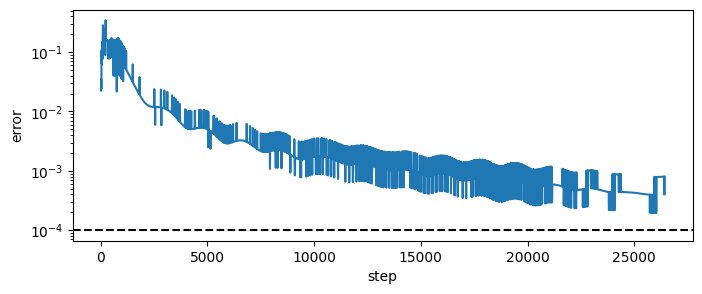

In [23]:
fig, ax = plt.subplots(figsize=(8, 3))
sns.lineplot(
    data=model.convergence_trajectory_df,
    x="step", 
    y="error",
    ax=ax
)
ax.set_yscale("log")
ax.axhline(1e-4, color="black", linestyle="--")
plt.show()

Next, let's look at the prediction accuracy, and global epistasis fit

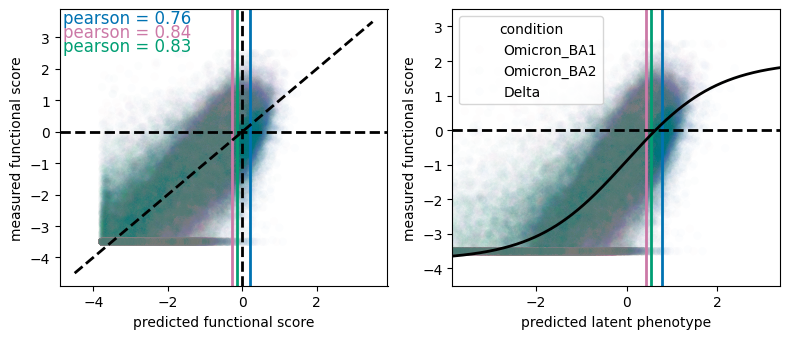

In [29]:
fig, ax = plt.subplots(1,2, figsize=(8, 3.5))
model.plot_pred_accuracy(ax=ax[0], show=False, alpha=0.01, legend=False, r=1)
model.plot_epistasis(ax=ax[1], show=False, alpha=0.01, legend=True)
plt.tight_layout()
plt.show()

Finally, we can look at the mutational parameters using the interactive heatmap method, `Model.mut_param_heatmap`

In [30]:
model.mut_param_heatmap()

alt.VConcatChart(...)